# LP vs VAR across IRF shapes — quick comparison

Quick check (not thesis-grade): **do the three IRF shapes actually lead to different LP-vs-VAR performance?**

We use one controlled DGP family so shape is the *only* thing that varies — a VAR(1) rotation
$A = \rho\,R(\theta)$ with the **same** persistence $\rho=0.9$ and the **same** recursive $B$ for all three.
Only the eigenvalue angle $\theta$ changes: $0^\circ$ = decaying, $12^\circ$ = hump, $45^\circ$ = oscillatory.

Two questions:
1. **Within a shape** — LP(4) vs the VAR sweep.
2. **Across shapes** — is LP (or VAR) itself better/worse on oscillatory vs hump vs decaying? (normalized RMSE, since the three IRFs have different magnitudes)

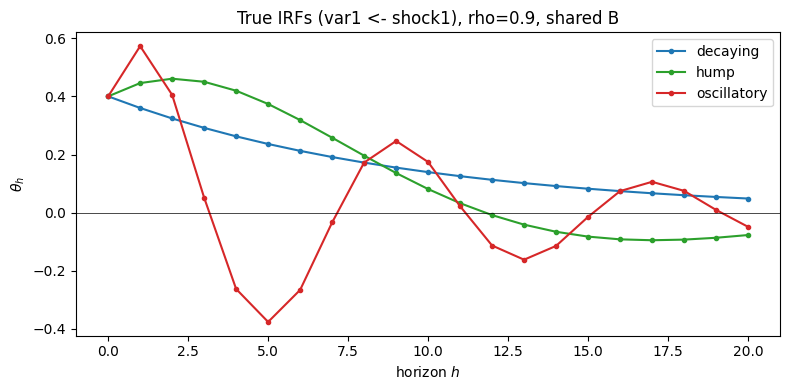

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import VARSpec, simulate_var, var_irf
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

RHO = 0.9
B = np.array([[0.4, 0.0], [0.5, 1.0]])     # shared recursive impact matrix (same for all shapes)
H = 20


def rot_spec(theta_deg):
    """VAR(1) with A = rho * R(theta): only the angle varies the shape."""
    th = np.deg2rad(theta_deg)
    A = RHO * np.array([[[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]]])
    return VARSpec(A, B)


SHAPES = {"decaying": rot_spec(0), "hump": rot_spec(12), "oscillatory": rot_spec(45)}
COLORS = {"decaying": "tab:blue", "hump": "tab:green", "oscillatory": "tab:red"}


def var_dgp(rng, T, spec):
    return simulate_var(spec, T, rng)


# sanity: the three true IRFs we are comparing against
hgrid = np.arange(H + 1)
fig, ax = plt.subplots(figsize=(8, 4))
for name, spec in SHAPES.items():
    ax.plot(hgrid, var_irf(spec, H), marker="o", ms=3, color=COLORS[name], label=name)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"True IRFs (var1 <- shock1), rho={RHO}, shared B")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$"); ax.legend()
fig.tight_layout(); plt.show()

## 1. Empirical frequency of the three types

In [2]:
from collections import Counter
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from mcsim.dgp import (
    VARSpec, simulate_var, var_irf, var_ma_matrices, scale_to_persistence,
    spectral_radius, companion,
)


def classify_irf(v, osc_tol=0.33):
    """Classify a signed IRF (response of var1 to shock1).

    - large opposite-side excursion relative to the peak -> oscillatory
    - otherwise a delayed peak (peak away from impact)     -> hump
    - otherwise (peak at impact, negligible swing)         -> decaying
    """
    peak = np.max(np.abs(v))
    if peak < 1e-12:
        return "decaying"
    peak_h = int(np.argmax(np.abs(v)))
    s0 = np.sign(v[0]) or 1.0
    osc_ratio = max(0.0, float(np.max(-s0 * v))) / peak
    if osc_ratio >= osc_tol:
        return "oscillatory"
    return "hump" if peak_h >= 1 else "decaying"


def random_spec(rng):
    """A random stable bivariate VAR(4): N(0,1) coefficients scaled to a random
    persistence in the thesis range (0.5, 0.95), with recursive (lower-triangular)
    identification. (One candidate sampling scheme -- proportions depend on it.)"""
    A0 = rng.standard_normal((4, 2, 2))
    rho = rng.uniform(0.5, 0.95)
    A = scale_to_persistence(A0, rho)
    Bd = np.diag(rng.uniform(0.5, 1.5, 2))
    Bl = np.tril(rng.normal(0, 0.5, (2, 2)), -1)
    return VARSpec(A, Bd + Bl)


rng = np.random.default_rng(42)
N = 100_000
H_cls = 24

labels = np.empty(N, dtype=object)
dom_mod = np.empty(N)   # modulus of dominant eigenvalue (= persistence)
dom_ang = np.empty(N)   # |angle| of dominant eigenvalue (cycle frequency)
for i in tqdm(range(N)):
    spec = random_spec(rng)
    labels[i] = classify_irf(var_irf(spec, H_cls))
    eig = np.linalg.eigvals(companion(spec.A))
    d = eig[np.argmax(np.abs(eig))]
    dom_mod[i] = abs(d)
    dom_ang[i] = abs(np.angle(d))

counts = Counter(labels)
print(f"over {N:,} random stable bivariate VAR(4):")
for k in ("decaying", "hump", "oscillatory"):
    print(f"  {k:12s}: {counts[k]/N:6.1%}  ({counts[k]})")

100%|██████████| 100000/100000 [00:11<00:00, 8617.78it/s]

over 100,000 random stable bivariate VAR(4):
  decaying    :  64.2%  (64175)
  hump        :   1.2%  (1221)
  oscillatory :  34.6%  (34604)


## 2. Run the Monte Carlo for each shape

Identical config for all three shapes — LP(4) plus a short VAR sweep, $T=240$, $H=20$, 2000 reps.

In [3]:
estimators = {"LP(4)": partial(estimate_lp_irf, p=4, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in (1, 2, 4, 8, 16)})

cfg = MCConfig(n_reps=2000, T=240, horizon=H, seed=20260527, n_jobs=-1, progress=True,
               estimators=estimators)

results, truth = {}, {}
for name, spec in SHAPES.items():
    results[name] = run(partial(var_dgp, spec=spec), cfg)
    truth[name] = var_irf(spec, H)

# RMSE by horizon, and a per-shape normalization (RMS of the true IRF) for cross-shape comparison
rmse = {sh: {nm: np.sqrt(np.nanmean((st - truth[sh]) ** 2, axis=0))
             for nm, st in results[sh]["irfs"].items()} for sh in SHAPES}
scale = {sh: np.sqrt(np.mean(truth[sh] ** 2)) for sh in SHAPES}
print("done. per-shape IRF scale:", {k: round(v, 3) for k, v in scale.items()})

MC reps: 100%|██████████| 2000/2000 [00:00<00:00, 5893.62it/s]


done. per-shape IRF scale: {'decaying': np.float64(0.199), 'hump': np.float64(0.256), 'oscillatory': np.float64(0.232)}


## 3. Within each shape: LP(4) vs the VAR sweep

LP(4) in bold red against the VAR orders. Raw RMSE (comparable within a panel).

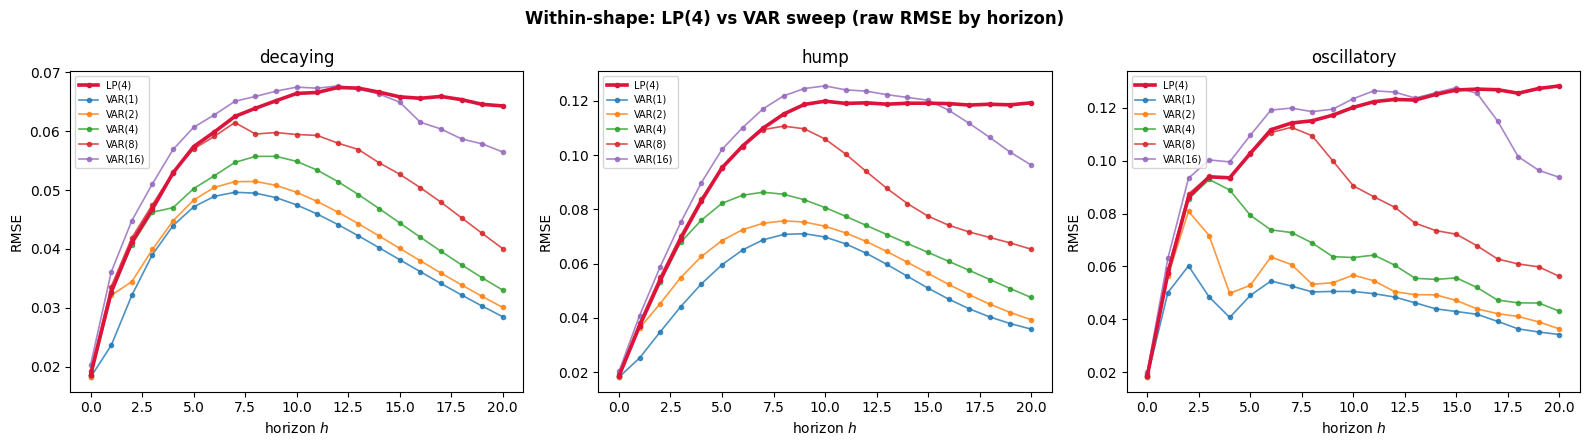

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, sh in zip(axes, SHAPES):
    for nm, r in rmse[sh].items():
        style = dict(lw=2.6, color="crimson", zorder=5) if nm == "LP(4)" else dict(lw=1.2, alpha=0.8)
        ax.plot(hgrid, r, marker="o", ms=3, label=nm, **style)
    ax.set_title(sh); ax.set_xlabel("horizon $h$"); ax.set_ylabel("RMSE"); ax.legend(fontsize=7)
fig.suptitle("Within-shape: LP(4) vs VAR sweep (raw RMSE by horizon)", fontweight="bold")
fig.tight_layout(); plt.show()

## 4. Across shapes: is each estimator itself shape-sensitive?

Normalized RMSE (÷ RMS of the true IRF) so the three shapes are comparable. Left: LP(4) across shapes; right: VAR(4) across shapes.

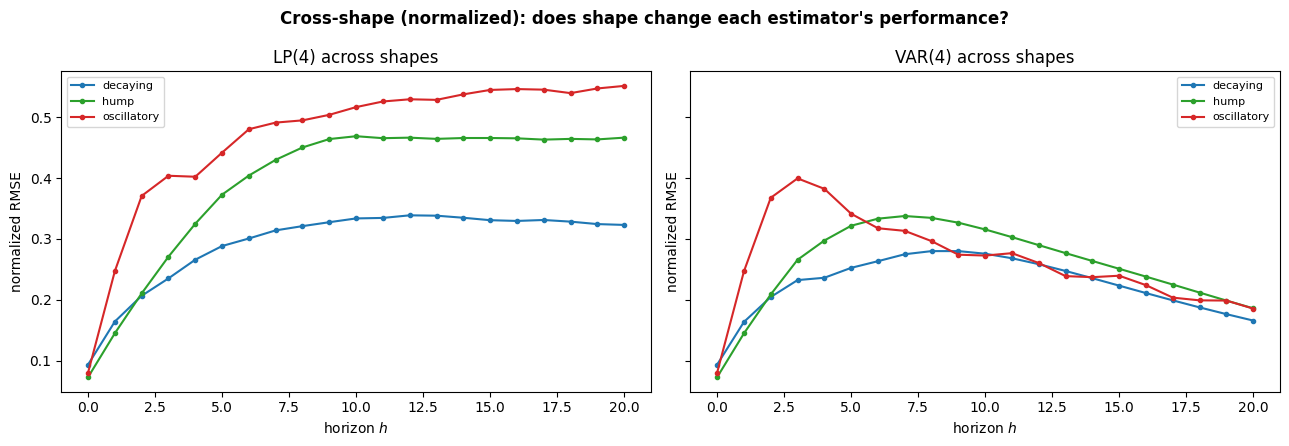

In [5]:
fig, (axL, axV) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for sh in SHAPES:
    axL.plot(hgrid, rmse[sh]["LP(4)"] / scale[sh], marker="o", ms=3, color=COLORS[sh], label=sh)
    axV.plot(hgrid, rmse[sh]["VAR(4)"] / scale[sh], marker="o", ms=3, color=COLORS[sh], label=sh)
axL.set_title("LP(4) across shapes"); axV.set_title("VAR(4) across shapes")
for ax in (axL, axV):
    ax.set_xlabel("horizon $h$"); ax.set_ylabel("normalized RMSE"); ax.legend(fontsize=8)
fig.suptitle("Cross-shape (normalized): does shape change each estimator's performance?", fontweight="bold")
fig.tight_layout(); plt.show()

## 5. Summary: horizon-averaged normalized RMSE

`LP-VAR4 > 0` means VAR(4) is better; `bestVAR` is the best order in the sweep for that shape.

In [6]:
print(f"{'shape':12s} {'LP(4)':>8s} {'VAR(4)':>8s} {'bestVAR':>8s} {'LP-VAR4':>9s}")
print("-" * 50)
for sh in SHAPES:
    lp = float(np.mean(rmse[sh]["LP(4)"] / scale[sh]))
    v4 = float(np.mean(rmse[sh]["VAR(4)"] / scale[sh]))
    best = min(float(np.mean(rmse[sh][nm] / scale[sh])) for nm in rmse[sh] if nm.startswith("VAR"))
    print(f"{sh:12s} {lp:8.3f} {v4:8.3f} {best:8.3f} {lp - v4:+9.3f}")
print("\n(horizon-averaged normalized RMSE)")

shape           LP(4)   VAR(4)  bestVAR   LP-VAR4
--------------------------------------------------
decaying        0.294    0.225    0.196    +0.068
hump            0.394    0.257    0.201    +0.136
oscillatory     0.468    0.265    0.193    +0.203

(horizon-averaged normalized RMSE)


## 6. Misspecified DGP: add an MA term (VARMA)

The check above is the *correctly-specified* regime (the DGP is a VAR), so the VAR wins everywhere. Now make the DGP a **VARMA(1,1)** — same rotation $A$ per shape, plus a shared MA term $\Theta = 0.5\,I$. A VARMA is a VAR($\infty$), so the finite LP(4)/VAR(q) estimators are now *misspecified*. This is the regime where LP's robustness (it doesn't iterate a truncated AR forward) can show up.

Everything else — estimators, $T$, reps, seed — is unchanged.

In [7]:
THETA = 0.5 * np.eye(2)   # MA(1) term: makes the true DGP a VAR(inf), so finite VARs are misspecified


def simulate_varma(rng, T, A1, Theta, Bmat, burnin=200):
    """VARMA(1,1): y_t = A1 y_{t-1} + u_t + Theta u_{t-1}, u_t = B eps_t."""
    k = A1.shape[0]
    n = T + burnin
    eps = rng.standard_normal((n, k))
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        u = eps @ Bmat.T
        y = np.zeros((n, k))
        for t in range(1, n):
            y[t] = A1 @ y[t - 1] + u[t] + Theta @ u[t - 1]
    return y[burnin:]


def varma_irf(A1, Theta, Bmat, horizon, shock=0, response=0):
    """True structural IRF of the VARMA(1,1): Psi_0=I, Psi_1=A1+Theta, Psi_h=A1 Psi_{h-1}."""
    k = A1.shape[0]
    psi = [np.eye(k)]
    for h in range(1, horizon + 1):
        psi.append(A1 @ psi[h - 1] + (Theta if h == 1 else np.zeros((k, k))))
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        theta = np.array(psi) @ Bmat
    return theta[:, response, shock]


results_ma, truth_ma = {}, {}
for name, spec in SHAPES.items():
    A1 = spec.A[0]   # rotation matrix for this shape (same as the VAR case)
    results_ma[name] = run(partial(simulate_varma, A1=A1, Theta=THETA, Bmat=B), cfg)
    truth_ma[name] = varma_irf(A1, THETA, B, H)

rmse_ma = {sh: {nm: np.sqrt(np.nanmean((st - truth_ma[sh]) ** 2, axis=0))
                for nm, st in results_ma[sh]["irfs"].items()} for sh in SHAPES}
scale_ma = {sh: np.sqrt(np.mean(truth_ma[sh] ** 2)) for sh in SHAPES}
print("done (VARMA). per-shape IRF scale:", {k: round(v, 3) for k, v in scale_ma.items()})

MC reps: 100%|██████████| 2000/2000 [00:00<00:00, 5321.79it/s]


done (VARMA). per-shape IRF scale: {'decaying': np.float64(0.292), 'hump': np.float64(0.377), 'oscillatory': np.float64(0.326)}


## 7. Within-shape under misspecification (VARMA)

Same plot as Section 1, now for the VARMA DGP. Watch whether LP(4) (bold red) moves below the low-order VARs at longer horizons.

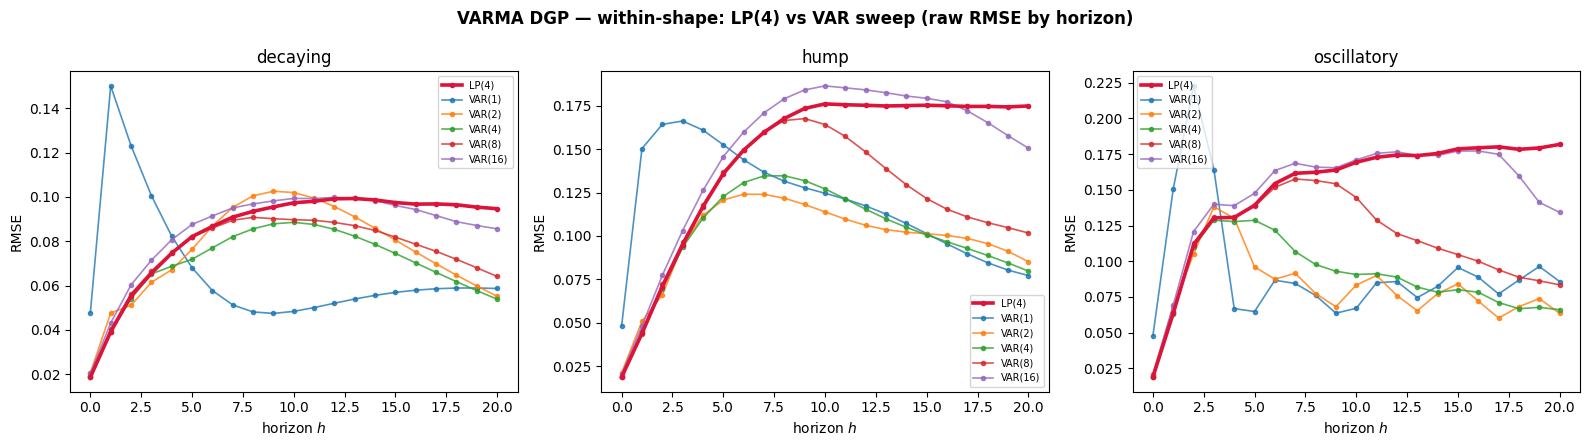

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, sh in zip(axes, SHAPES):
    for nm, r in rmse_ma[sh].items():
        style = dict(lw=2.6, color="crimson", zorder=5) if nm == "LP(4)" else dict(lw=1.2, alpha=0.8)
        ax.plot(hgrid, r, marker="o", ms=3, label=nm, **style)
    ax.set_title(sh); ax.set_xlabel("horizon $h$"); ax.set_ylabel("RMSE"); ax.legend(fontsize=7)
fig.suptitle("VARMA DGP — within-shape: LP(4) vs VAR sweep (raw RMSE by horizon)", fontweight="bold")
fig.tight_layout(); plt.show()

## 8. Does the ranking flip?

Side-by-side LP−VAR(4) gap: the correctly-specified VAR DGP vs the misspecified VARMA DGP, same three shapes.

In [9]:
print("Did the ranking change? horizon-averaged normalized LP-VAR4 gap")
print("(> 0 = VAR(4) better, < 0 = LP better)\n")
print(f"{'shape':12s} {'VAR DGP':>9s} {'VARMA DGP':>10s} {'change':>9s}")
print("-" * 44)
for sh in SHAPES:
    gap_var = float(np.mean(rmse[sh]["LP(4)"] / scale[sh] - rmse[sh]["VAR(4)"] / scale[sh]))
    gap_ma = float(np.mean(rmse_ma[sh]["LP(4)"] / scale_ma[sh] - rmse_ma[sh]["VAR(4)"] / scale_ma[sh]))
    print(f"{sh:12s} {gap_var:+9.3f} {gap_ma:+10.3f} {gap_ma - gap_var:+9.3f}")
print("\n'change' < 0 means LP gained ground (or overtook) once the DGP became misspecified.")

Did the ranking change? horizon-averaged normalized LP-VAR4 gap
(> 0 = VAR(4) better, < 0 = LP better)

shape          VAR DGP  VARMA DGP    change
--------------------------------------------
decaying        +0.068     +0.051    -0.017
hump            +0.136     +0.119    -0.017
oscillatory     +0.203     +0.193    -0.010

'change' < 0 means LP gained ground (or overtook) once the DGP became misspecified.


## 9. Combined findings — correct vs misspecified

The full grid in one place: **LP(4)** and **VAR(4)** (and their gap) for each of the **3 shapes**, under the **correct (VAR)** and **misspecified (VARMA)** DGPs — shown in both **raw** and **normalized** RMSE.

**Takeaways:**
1. **Shape matters far more for LP than for VAR** — LP's error climbs steeply decaying → hump → oscillatory, while VAR(4) stays nearly flat (read across the rows of either DGP block).
2. **VAR(4) wins in every cell** of both DGPs (LP-VAR4 > 0 throughout).
3. **Misspecification does not help LP here.** In **raw** RMSE both estimators get ~40% worse under the VARMA and VAR(4)'s lead *widens*. The *normalized* numbers fall under the VARMA only because its true IRF is larger (a denominator effect) — so normalized comparisons are valid **within** a DGP (across shapes) but misleading **across** DGPs.

In [10]:
import pandas as pd
from IPython.display import display


def raw_rmse(results_d, truth_d, sh, nm):
    """Horizon-averaged RAW RMSE for one estimator/shape."""
    stack = results_d[sh]["irfs"][nm]
    return float(np.mean(np.sqrt(np.nanmean((stack - truth_d[sh]) ** 2, axis=0))))


def build(normalize):
    rows = {}
    for sh in SHAPES:
        lp_v, v4_v = raw_rmse(results, truth, sh, "LP(4)"), raw_rmse(results, truth, sh, "VAR(4)")
        lp_m, v4_m = raw_rmse(results_ma, truth_ma, sh, "LP(4)"), raw_rmse(results_ma, truth_ma, sh, "VAR(4)")
        if normalize:
            lp_v, v4_v = lp_v / scale[sh], v4_v / scale[sh]
            lp_m, v4_m = lp_m / scale_ma[sh], v4_m / scale_ma[sh]
        rows[sh] = {
            ("VAR DGP (correct)", "LP(4)"): lp_v,
            ("VAR DGP (correct)", "VAR(4)"): v4_v,
            ("VAR DGP (correct)", "LP-VAR4"): lp_v - v4_v,
            ("VARMA DGP (misspec.)", "LP(4)"): lp_m,
            ("VARMA DGP (misspec.)", "VAR(4)"): v4_m,
            ("VARMA DGP (misspec.)", "LP-VAR4"): lp_m - v4_m,
        }
    df = pd.DataFrame(rows).T.round(4)
    df.index.name = "shape"
    return df


print("Horizon-averaged RMSE. LP(4) vs VAR(4) x {decaying, hump, oscillatory} x {VAR, VARMA} DGP.")
print("LP-VAR4 > 0 means VAR(4) is better.\n")
print("RAW RMSE (actual units) -- the honest 'who is better' measure:")
display(build(normalize=False))
print("NORMALIZED RMSE (/ per-DGP IRF scale) -- comparable across shapes WITHIN a DGP,")
print("but not across DGPs (the VARMA's larger IRF shrinks its normalized numbers):")
display(build(normalize=True))

Horizon-averaged RMSE. LP(4) vs VAR(4) x {decaying, hump, oscillatory} x {VAR, VARMA} DGP.
LP-VAR4 > 0 means VAR(4) is better.

RAW RMSE (actual units) -- the honest 'who is better' measure:


VAR DGP (correct)                 VARMA DGP (misspec.)          \
                        LP(4)  VAR(4) LP-VAR4                LP(4)  VAR(4)   
shape                                                                        
decaying               0.0584  0.0448  0.0136               0.0844  0.0694   
hump                   0.1007  0.0658  0.0349               0.1456  0.1006   
oscillatory            0.1088  0.0615  0.0473               0.1514  0.0884   

                     
            LP-VAR4  
shape                
decaying      0.015  
hump          0.045  
oscillatory   0.063

NORMALIZED RMSE (/ per-DGP IRF scale) -- comparable across shapes WITHIN a DGP,
but not across DGPs (the VARMA's larger IRF shrinks its normalized numbers):


VAR DGP (correct)                 VARMA DGP (misspec.)          \
                        LP(4)  VAR(4) LP-VAR4                LP(4)  VAR(4)   
shape                                                                        
decaying               0.2935  0.2252  0.0683               0.2893  0.2378   
hump                   0.3935  0.2572  0.1363               0.3856  0.2665   
oscillatory            0.4680  0.2645  0.2035               0.4648  0.2715   

                     
            LP-VAR4  
shape                
decaying     0.0515  
hump         0.1192  
oscillatory  0.1933

## 10. Does naive DGP randomization bias the LP-vs-VAR comparison?

When you average LP-vs-VAR performance over naively randomized DGPs, you report a **frequency-weighted mixture**:

$$G_{\text{naive}} = \sum_s P_{\text{naive}}(s)\,\bar g(s),\qquad \bar g(s)=\mathbb{E}[\text{gap}\mid \text{shape}=s]$$

with gap = per-DGP normalized $\text{RMSE}_{LP}-\text{RMSE}_{VAR}$. Since one shape dominates the random frequencies (§1), the average is pulled toward that regime — so the reported number can over- or under-state LP's disadvantage relative to a weighting you actually care about.

**Method:** (1) take $P_{\text{naive}}(s)$ from §1's 100k classification; (2) estimate $\bar g(s)$ on genuinely random DGPs, *stratified* (draw until each shape has $K$ MC-evaluated DGPs) so the rare hump class isn't too noisy; (3) recombine $\bar g(s)$ under several weightings — the **bias** vs a target is $\sum_s[P_{\text{naive}}(s)-P_{\text{target}}(s)]\,\bar g(s)$; (4) decompose the gap variance into between- vs within-shape ($\eta^2$ = share explained by *which shape you drew*).

> "Bias" is defined **relative to a chosen target weighting** — a value judgment about which shapes matter — so we show several (uniform, all-oscillatory, all-decaying) rather than one number.

In [11]:
# ---- 10. Composition bias of naive DGP randomization ------------------------
# Per-shape LP-VAR gap measured on GENUINELY RANDOM DGPs (the section-1 generator),
# stratified so the rare hump class gets enough MC-evaluated draws.

P_naive = {s: counts[s] / N for s in ("decaying", "hump", "oscillatory")}  # from section 1 (100k)

K = 100  # MC-evaluated random DGPs per shape
cfg10 = MCConfig(n_reps=500, T=240, horizon=H, seed=777, n_jobs=-1, progress=False,
                 estimators={"LP(4)": partial(estimate_lp_irf, p=4, horizon=H),
                             "VAR(4)": partial(estimate_var_irf, p=4, horizon=H)})


def lp_var_gap(spec):
    """Return (raw gap, normalized gap, IRF scale) for one DGP. gap = RMSE_LP - RMSE_VAR4."""
    tr = var_irf(spec, H)
    sc = np.sqrt(np.mean(tr ** 2))
    r = run(partial(var_dgp, spec=spec), cfg10)
    lp = float(np.mean(np.sqrt(np.nanmean((r["irfs"]["LP(4)"] - tr) ** 2, axis=0))))
    v4 = float(np.mean(np.sqrt(np.nanmean((r["irfs"]["VAR(4)"] - tr) ** 2, axis=0))))
    return lp - v4, (lp - v4) / sc, sc


rng10 = np.random.default_rng(2024)
recs = {s: [] for s in P_naive}
need = dict.fromkeys(P_naive, K)
n_draws = 0
while any(need[s] > 0 for s in need):
    spec = random_spec(rng10)
    n_draws += 1
    s = classify_irf(var_irf(spec, H_cls))
    if need[s] > 0:
        recs[s].append(lp_var_gap(spec))
        need[s] -= 1
print(f"classified {n_draws} random DGPs to fill K={K} per shape ({3 * K} MC runs)")

nrm = {s: np.array([r[1] for r in recs[s]]) for s in recs}       # normalized gap per DGP
raw = {s: np.array([r[0] for r in recs[s]]) for s in recs}
scl = {s: np.array([r[2] for r in recs[s]]) for s in recs}
gbar = {s: float(nrm[s].mean()) for s in recs}                   # E[gap | shape]
gse = {s: float(nrm[s].std(ddof=1) / np.sqrt(K)) for s in recs}
gvar = {s: float(nrm[s].var(ddof=1)) for s in recs}

order = ["decaying", "hump", "oscillatory"]
per_shape = pd.DataFrame({
    "P_naive": {s: P_naive[s] for s in order},
    "raw gap": {s: float(raw[s].mean()) for s in order},
    "IRF scale": {s: float(scl[s].mean()) for s in order},
    "norm gap (LP-VAR)": {s: gbar[s] for s in order},
    "± SE": {s: gse[s] for s in order},
}).round(4)
print("\nPer-shape LP-VAR gap on random DGPs (gap > 0 = VAR better):")
display(per_shape)

# Reweighting: average normalized gap under different shape weightings
W = {
    "naive (random freq.)": P_naive,
    "uniform over shapes": {s: 1 / 3 for s in P_naive},
    "all oscillatory": {"decaying": 0.0, "hump": 0.0, "oscillatory": 1.0},
    "all decaying": {"decaying": 1.0, "hump": 0.0, "oscillatory": 0.0},
}
G = {name: sum(w[s] * gbar[s] for s in gbar) for name, w in W.items()}
Gn = G["naive (random freq.)"]
reweight = pd.DataFrame({
    "avg gap": G,
    "bias vs naive": {name: G[name] - Gn for name in G},
}).round(4)
print("Average LP-VAR gap under different shape weightings (bias vs naive > 0 => naive understates):")
display(reweight)

# Variance decomposition: share of gap variance attributable to shape composition
between = sum(P_naive[s] * (gbar[s] - Gn) ** 2 for s in P_naive)
within = sum(P_naive[s] * gvar[s] for s in P_naive)
eta2 = between / (between + within)
print(f"Variance decomposition of the gap under the naive mixture:")
print(f"  between-shape variance : {between:.5f}")
print(f"  within-shape variance  : {within:.5f}")
print(f"  eta^2 (share of gap variance explained by SHAPE) : {eta2:.1%}")

classified 8878 random DGPs to fill K=100 per shape (300 MC runs)

Per-shape LP-VAR gap on random DGPs (gap > 0 = VAR better):


,P_naive,raw gap,IRF scale,norm gap (LP-VAR),± SE
decaying,0.6418,0.0499,0.2584,0.2013,0.0050
hump,0.0122,0.0572,0.4847,0.1434,0.0088
oscillatory,0.3460,0.0475,0.2987,0.1752,0.0064


Average LP-VAR gap under different shape weightings (bias vs naive > 0 => naive understates):


,avg gap,bias vs naive
naive (random freq.),0.1916,0.0000
uniform over shapes,0.1733,-0.0183
all oscillatory,0.1752,-0.0164
all decaying,0.2013,0.0097


Variance decomposition of the gap under the naive mixture:
  between-shape variance : 0.00018
  within-shape variance  : 0.00310
  eta^2 (share of gap variance explained by SHAPE) : 5.6%


### What we find (K=100) — it overturns the hypothesis

On **genuinely random** DGPs the composition bias is **negligible**, and the worry — that the decaying-heavy mix understates LP's badness — does **not** hold:

1. **Per-shape gaps are similar**, all favoring VAR: normalized LP−VAR ≈ 0.14–0.20. In **raw** terms they're nearly identical (~0.048–0.057); the normalized spread is mostly a *scale* effect (decaying DGPs have the smallest IRFs → largest normalized gap; hump the largest IRFs → smallest). So decaying shows the *largest* normalized gap, not the smallest — the opposite of the controlled rotation family in §3–5.
2. **Reweighting barely moves the average.** naive 0.192 → uniform 0.173 (a −0.018 change, ~10% of the gap), and in the *opposite* direction to the hypothesis: because random decaying DGPs have the biggest normalized gap, the decaying-heavy naive mix slightly *over*-states LP's disadvantage, not under-states it.
3. **Shape explains almost none of the variation:** $\eta^2 \approx 5.6\%$. ~94% of the gap variance is *within* shape — driven by other features (chiefly persistence) and MC noise, not shape class. (This $\eta^2$ is *downward*-biased: "within-shape" still contains per-DGP Monte-Carlo noise from the 500 reps/DGP, so the true shape share is a bit higher — but the between-shape component is small enough that the verdict holds.)

**Why this differs from §3–5:** that controlled experiment fixed $\rho=0.9$ and varied only the eigenvalue angle, isolating shape. Once you randomize *all* coefficients (persistence $\rho \sim U(0.5,0.95)$ included), persistence and other factors dominate and the pure shape channel nearly vanishes. So the dramatic "LP much worse on oscillatory" is real *at fixed high persistence* but is not what drives differences across a randomized DGP family.

**Bottom line:** naive randomization does **not** materially bias the LP-vs-VAR comparison through shape composition (≈0.018, ~10%, wrong-signed for the worry). The real lever is **persistence**, not shape — so a defensible randomized headline should stratify/report by *persistence*, not by shape. *(Caveat: specific to this coefficient-sampling scheme; a different generator could shift the frequencies and per-shape gaps.)*